# Exploratory data analysis on the dsn mart data 

This Basic EDA Notebook was modelled after [chris deolites notebook on Basic EDA](https://www.kaggle.com/code/cdeotte/basic-eda-customer-churn/)

## Phase: 1 Importing needed libraries and the data 

In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import sqlite3


from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

from sklearn.preprocessing import PowerTransformer

In [3]:
# major directory file_path.
DIR = "/kaggle/input/competitions/dsn-bootcamp-qualification-hackathon-2026-ml-track/"


# specific filepaths
train_path = f"{DIR}train.csv"
test_path = f"{DIR}test.csv"
sample_path = f"{DIR}sample_submission.csv"

# importing the files using pandas read_csv
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)

In [3]:

def normalize_capitalization(df, old_column):
    """
    Normalizes case/whitespace duplicates in a categorical column
    (e.g. 'seafood', 'SEAFOOD', 'SeaFood' -> 'seafood') and writes
    the result into a new column.
    
    params: 
    df - your dataframe
    old_column - column with inconsistent capitalization
    new_column - column with corrected capitalization
    """
    df = df.copy()
    df[old_column] = (df[old_column]
        .astype(str)
        .str.strip()
        .str.lower())
    
    return df

In [4]:
train = normalize_capitalization(train, "product_category")

In [5]:
test = normalize_capitalization(test, "product_category")

## Phase: 2  Basic EDA 

In [6]:
# check the data
# Hide this 
def basic_data(df: pd.DataFrame, name: str, for_y = 0):
    """
    function prints the shape of the data
    """
    if for_y == 0:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows and {shape[1]} Columns")
        print('*'* 30)
    else:
        shape = df.shape
        print(f"The {name} dataframe has {shape[0]} Rows")
        print('*'* 30)

In [7]:
basic_data(train, "train")
basic_data(test, "test")
basic_data(sample, "sample_submission")

The train dataframe has 6818 Rows and 13 Columns
******************************
The test dataframe has 1705 Rows and 12 Columns
******************************
The sample_submission dataframe has 1705 Rows and 2 Columns
******************************


### Description of the columns in the train data 
|column|Description|
|------|-----------|
|id| Unique row identifier|
| product_code| Unique code for the product|
|product_weight_kg |	Weight of the product in kilograms (some values are missing)|
|fat_content |	Whether the product is labelled "Low Fat" or "Regular"|
|shelf_visibility |	The proportion of total display area in the store allocated to this product|
|product_category |	The product's category (note: capitalization is inconsistent — that's real-world data, not a bug)|
|product_price |	The product's listed price|
|store_code |	Unique code for the store|
|store_size |	The store's size category: Small, Medium, or Large (some values are missing)|
|store_location_tier |	The tier of the store's location — Tier_1 (major urban centers), Tier_2 (state capitals), Tier_3 (smaller towns)|
|store_format |	The store's format: Corner Shop, Standard Supermarket, Superstore, or Flagship Hypermarket|
|total_sales |	Target. Total sales value for this product at this store (train only)|

In [8]:
# print the percentage of missing values in the df per column 
""" we are dividing the total missing values in a column/by the total no of rows 
    then multiplying it by 100 giving the percent missing values if you want the
    total missing values modify the function """
def check_nan_state(df, name):
    total_rows = len(df)
    if total_rows == 0:
        print("Dataframe is empty !!!")
    else:
        nan_percent = (df.isna().sum()/ total_rows * 100).round(2)
        nan_percent_display = pd.DataFrame({"Column" : nan_percent.index,
                                            "Percent missing" : nan_percent.values}).sort_values("Percent missing"
                                                                                                 , ascending = False)
        print(f"Percent values of NAN values in {name} dataframe ")
        display(nan_percent_display)

In [9]:
check_nan_state(train, "train")

Percent values of NAN values in train dataframe 


,Column,Percent missing
9,store_size,28.15
2,product_weight_kg,17.97
0,id,0.00
3,fat_content,0.00
1,product_code,0.00
4,shelf_visibility,0.00
5,product_category,0.00
7,store_code,0.00
6,product_price,0.00
8,store_age_years,0.00


In [10]:
# check out the statistical distribution of the numerical columns in the df
train.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,5593.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.850876,0.065527,140.473623,34.178205,2174.756574
std,4.646542,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.750000,0.026600,93.280000,28.000000,834.792500
50%,12.647000,0.053200,142.065000,33.000000,1790.890000
75%,16.894000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


notice that spike from 75% percentile total sales of 3k to 100% percentile total sales of 12k some thing is there

- the 12k total sales is  under `HOUSEHOLD`, `fruitsandvegitables` in product_category
- we also have 10k total sales under `Dairy` in the product_category i would do a more indepth search on this spike it might be outliers

now checking from store formats this follows normal conventions 
|store_format|   total_sales |
|------------|------------------|
|Corner Shop  |            1830.37|
|Flagship Hypermarket |   12996.82|
|Standard Supermarket |   10130.90|
|Superstore          |     7016.22|

but what does not follow normal conventions is that all the flagship Hypermarkets are (Store_location_tier)Tier_3(small towns )


### NAN value Analysis 
i have noticed that the NAN values can be consistent (like there are patterns to the missing data )
so this section is my indepth analysis on it 
this is me trying to enter the shoes of the person that scrambled the data (in a way)

#### Flagship Hypermarket EDA Find all NAN values in the product_weight_kg colum
Found this detail by mistake see that the categorical value Flagship Hypermarket doesnt have any product_weight_kg 
so my solution would be instead of taking the global mean for filling the nan values 

we use the product_category column to check for each products mean/average weight then use that to fill the nan values 
works well no well we explore also if it works well 

In [11]:
train["store_format"].value_counts()

store_format
Standard Supermarket    4462
Corner Shop              866
Flagship Hypermarket     748
Superstore               742
Name: count, dtype: int64

In [13]:
store_format_by_product_weight = train.groupby("store_format")["product_weight_kg"].mean()

store_format_by_product_weight

store_format
Corner Shop             12.991228
Flagship Hypermarket          NaN
Standard Supermarket    12.820999
Superstore              12.946845
Name: product_weight_kg, dtype: float64

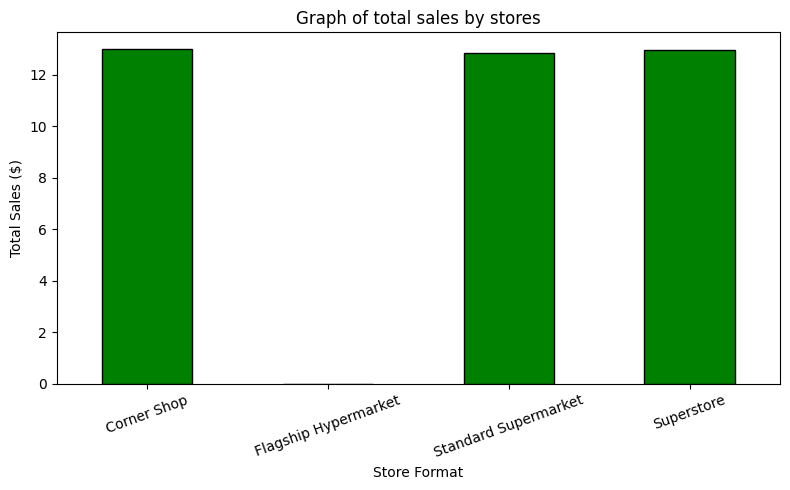

In [12]:
fig, ax = plt.subplots(figsize=(8, 5))
store_format_by_product_weight.plot(kind='bar', ax=ax, color='green', edgecolor='black')
ax.set_title('relationship between store_format and product_weight_kg')
ax.set_xlabel('Store Format')
ax.set_ylabel('product weight')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [14]:
# See how many NaNs exist per group, and group sizes
train.groupby("store_format")["product_weight_kg"].agg(['count', 'size'])

,count,size
store_format,,
Corner Shop,439,866
Flagship Hypermarket,0,748
Standard Supermarket,4420,4462
Superstore,734,742


when using groupby mean the function ignores the nan values to calculate the mean 
so it is very curious that mean of the groupby of store_format and product_weight = 'Flagship Hypermarket' has a NAN value which means that all the rows that have this relationship are NAN values

-------------------------------------------------
### store_size nan analysis 
now to observe on the store_size column and check if theres any correlation like the above there also 

thinking maybe corner_shop has no tier_3 shops  all of it are NAN values 
like if the store format is `corner shop` and the store_location_tier is `Tier_3` the value of the store_size is garanteed to be a NAN value

In [68]:
pd.crosstab(train['store_size'], train['store_format'])

store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
store_size,,,,
Large,0,0,748,0
Medium,0,748,728,742
Small,427,0,1506,0


- so from the detail above all corner shops should be of `small` store_size most of then are nan 400+
but for standard supermarket with spread out shops we cant be sure that most frequent is the correct way to fill the nan values

In [69]:
pd.crosstab(train['store_location_tier'], train['store_format'])

store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
store_location_tier,,,,
Tier_1,427,0,1482,0
Tier_2,0,0,2232,0
Tier_3,439,748,748,742


In [17]:
pd.crosstab(train['store_location_tier'], train['store_size'])

store_size,Large,Medium,Small
store_location_tier,,,
Tier_1,0,728,1181
Tier_2,0,0,752
Tier_3,748,1490,0


In [70]:
# this checks my hypotesis that if the store_format is Corner shop and the store_location_tier is tier_3 
# then the value of the store_size would be NAN also notice that in the above the Tier_3 of corner_shop is 439 

mask = (train['store_format'] == 'Corner Shop') & (train['store_location_tier'] == 'Tier_3')
subset = train[mask]

print("Total rows in this combo:", len(subset))
print("NaN count in store_size:", subset['store_size'].isna().sum())
print("Non-NaN count in store_size:", subset['store_size'].notna().sum())

Total rows in this combo: 439
NaN count in store_size: 439
Non-NaN count in store_size: 0


In [71]:
combo_check = train.groupby(['store_format', 'store_location_tier'])['store_size'].agg(['count', 'size'])
combo_check['all_nan'] = combo_check['count'] == 0
print(combo_check[combo_check['all_nan']])

                                  count  size  all_nan
store_format store_location_tier                      
Corner Shop  Tier_3                   0   439     True


In [72]:
pd.crosstab(train['store_format'], train['store_location_tier'], 
            values=train['store_size'].isna(), aggfunc='mean')

store_location_tier,Tier_1,Tier_2,Tier_3
store_format,,,
Corner Shop,0.0,NaN,1.0
Flagship Hypermarket,NaN,NaN,0.0
Standard Supermarket,0.0,0.663082,0.0
Superstore,NaN,NaN,0.0


In [3]:
pd.crosstab(train['store_location_tier'], train['store_code'])

store_code,STORE-7WS,STORE-89Z,STORE-9RG,STORE-AGY,STORE-DKU,STORE-HL7,STORE-JOR,STORE-OYG,STORE-T5G,STORE-YLW
store_location_tier,,,,,,,,,,
Tier_1,0,728,0,0,0,0,0,0,427,754
Tier_2,0,0,752,0,736,0,0,744,0,0
Tier_3,748,0,0,748,0,742,439,0,0,0


In [9]:
pd.crosstab(train['store_code'], train['store_size'])
# this is curious the listed store code is 7 but there are 10 store_codes 

store_size,Large,Medium,Small
store_code,,,
STORE-7WS,0,748,0
STORE-89Z,0,728,0
STORE-9RG,0,0,752
STORE-AGY,748,0,0
STORE-HL7,0,742,0
STORE-T5G,0,0,427
STORE-YLW,0,0,754


In [16]:
# check coverage
train.groupby('store_format')['store_size'].agg(['count', 'size'])

,count,size
store_format,,
Corner Shop,427,866
Flagship Hypermarket,748,748
Standard Supermarket,2982,4462
Superstore,742,742


In [22]:
pd.crosstab(train['store_format'], train['store_size'])

store_size,Large,Medium,Small
store_format,,,
Corner Shop,0,0,427
Flagship Hypermarket,0,748,0
Standard Supermarket,748,728,1506
Superstore,0,742,0


In [20]:
#train.groupby('store_format')['store_size'].agg(['count', 'size'])
train.groupby('store_location_tier')['store_size'].agg(['count', 'size'])

,count,size
store_location_tier,,
Tier_1,1909,1909
Tier_2,752,2232
Tier_3,2238,2677


In [25]:
pd.crosstab([train['store_size'], train['store_location_tier']], train['store_format'])

store_format                    Corner Shop  Flagship Hypermarket  \
store_size store_location_tier                                      
Large      Tier_3                         0                     0   
Medium     Tier_1                         0                     0   
           Tier_3                         0                   748   
Small      Tier_1                       427                     0   
           Tier_2                         0                     0   

store_format                    Standard Supermarket  Superstore  
store_size store_location_tier                                    
Large      Tier_3                                748           0  
Medium     Tier_1                                728           0  
           Tier_3                                  0         742  
Small      Tier_1                                754           0  
           Tier_2                                752           0

In [11]:
all_categories = train['store_code'].unique()
crosstab_result = pd.crosstab(train['store_code'], train['store_size'])
present_categories = crosstab_result.index

missing = set(all_categories) - set(present_categories)
print("Categories not appearing at all in the crosstab:", missing)

Categories not appearing at all in the crosstab: {'STORE-OYG', 'STORE-DKU', 'STORE-JOR'}


In [23]:
pd.crosstab(train['store_location_tier'], train['store_format'])

store_format,Corner Shop,Flagship Hypermarket,Standard Supermarket,Superstore
store_location_tier,,,,
Tier_1,427,0,1482,0
Tier_2,0,0,2232,0
Tier_3,439,748,748,742


In [74]:
mask = (train['store_format'] == 'Standard Supermarket') & (train['store_location_tier'] == 'Tier_2')
subset = train[mask]

print("Total rows in this combo:", len(subset))
print("NaN count in store_size:", subset['store_size'].isna().sum())
print("Non-NaN count in store_size:", subset['store_size'].notna().sum())

Total rows in this combo: 2232
NaN count in store_size: 1480
Non-NaN count in store_size: 752


In [75]:
train.isna().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

what this means is that of the nan values in the store_size column (439) have this relationship (thier `store_format` column categorical value is 'Corner shop' and thier `Store_location_tier` categorical value is `Tier_3`)
and for the remaining nan values (1480)(thier `store_format` column categorical value is 'Standard Supermarket' and thier `Store_location_tier` categorical value is `Tier_2`)

totaling-1919

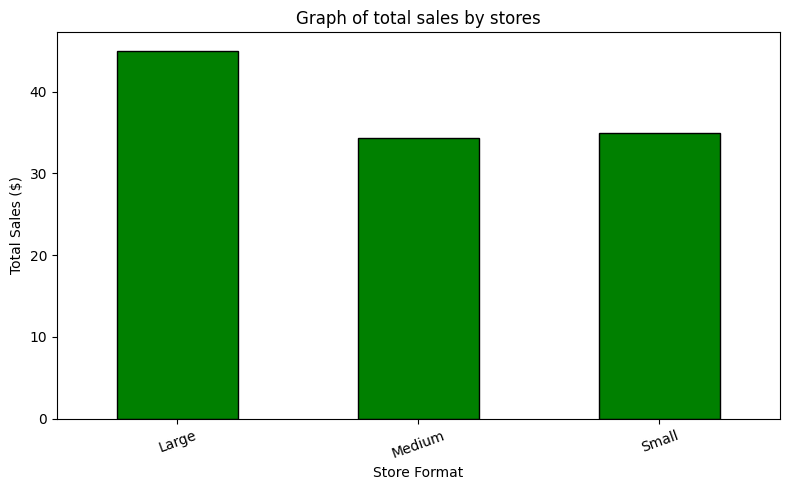

In [76]:
store_format_by_total_sales = train.groupby("store_size")["store_age_years"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
store_format_by_total_sales.plot(kind='bar', ax=ax, color='green', edgecolor='black')
ax.set_title('Graph of total sales by stores')
ax.set_xlabel('Store Format')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

#### Other EDA 

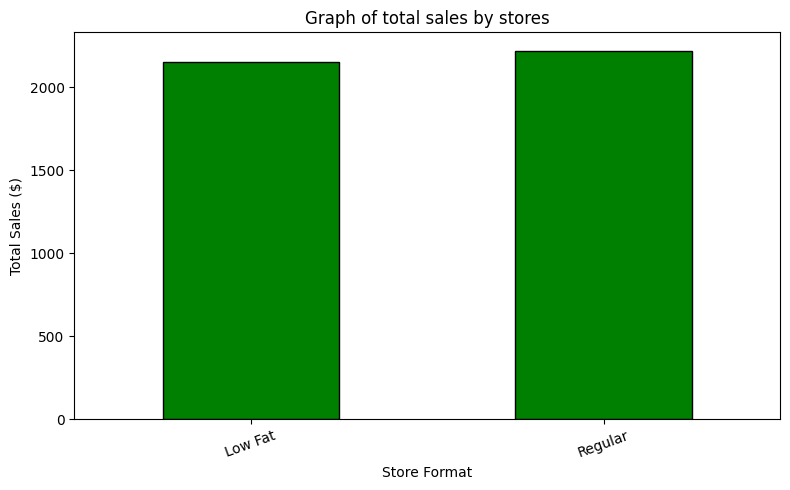

In [77]:
store_format_by_total_sales = train.groupby("fat_content")["total_sales"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
store_format_by_total_sales.plot(kind='bar', ax=ax, color='green', edgecolor='black')
ax.set_title('Graph of total sales by stores')
ax.set_xlabel('Store Format')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### Total Sales distribution Analysis

In [78]:
print("total sales distribution:")
print(f"  Mean:     {train['total_sales'].mean():.2f}")
print(f"  Median:   {train['total_sales'].median():.2f}")
print(f"  Max:      {train['total_sales'].max():.2f}")
print(f"  Skewness: {train['total_sales'].skew():.2f}  ← Somewhat skewed")
print()
print("After log1p transform:")
print(f"  Skewness: {np.log1p(train['total_sales']).skew():.2f}  ← much better")

total sales distribution:
  Mean:     2174.76
  Median:   1790.89
  Max:      12996.82
  Skewness: 1.15  ← Somewhat skewed

After log1p transform:
  Skewness: -0.90  ← much better


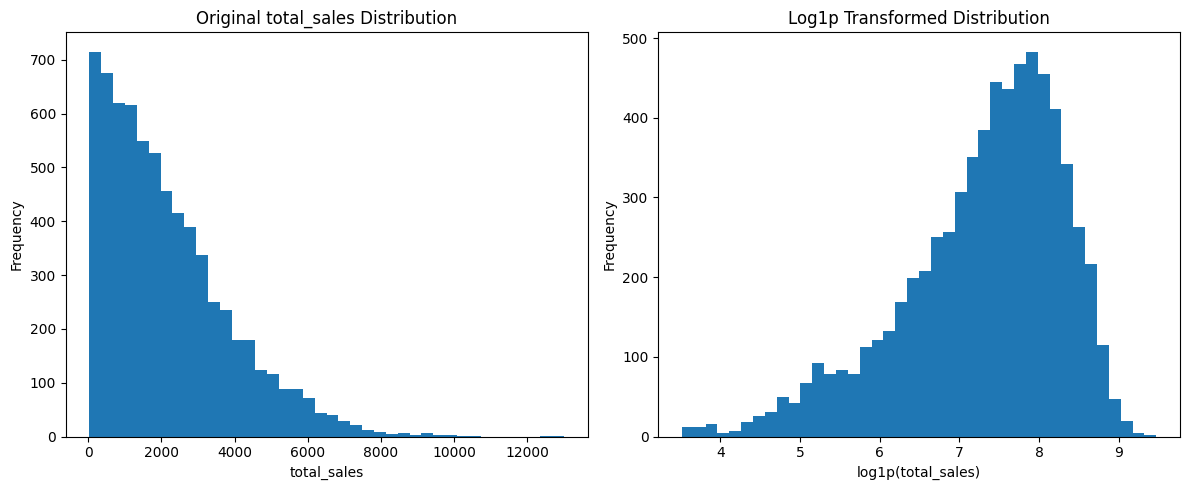

Original skewness: 1.15
Log1p skewness: -0.9


In [79]:
# Original total_sales values
original = train["total_sales"]

# Log-transformed values
log_transformed = np.log1p(original)

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original total_sales Distribution")
plt.xlabel("total_sales")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(log_transformed, bins=40)
plt.title("Log1p Transformed Distribution")
plt.xlabel("log1p(total_sales)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("Log1p skewness:", round(log_transformed.skew(), 2))

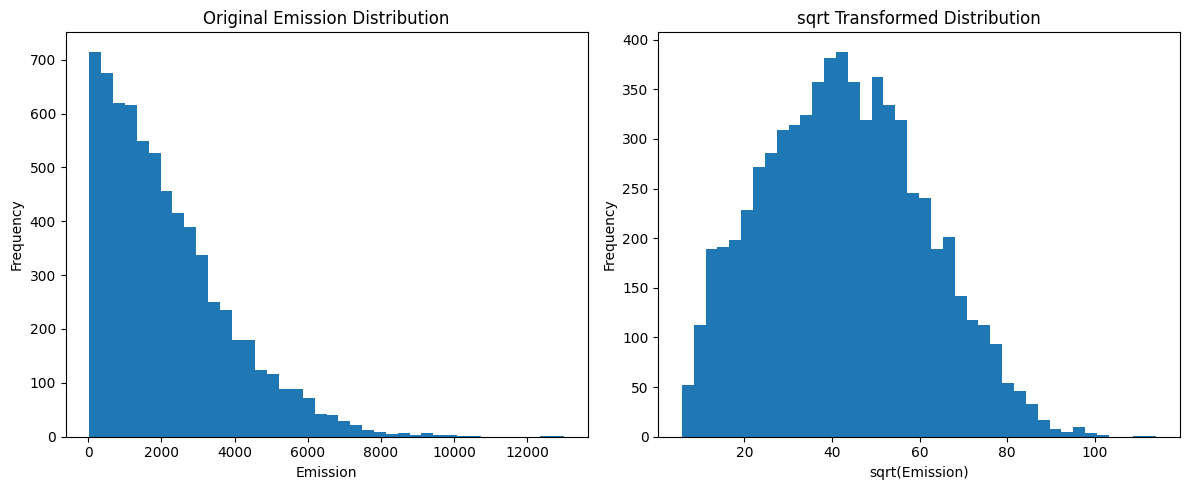

Original skewness: 1.15
sqrt skewness: 0.23


In [80]:
# Original emission values
original = train["total_sales"]

# Log-transformed values
log_transformed = np.sqrt(original)

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original Emission Distribution")
plt.xlabel("Emission")
plt.ylabel("Frequency")

# Log-transformed distribution
plt.subplot(1, 2, 2)
plt.hist(log_transformed, bins=40)
plt.title("sqrt Transformed Distribution")
plt.xlabel("sqrt(Emission)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("sqrt skewness:", round(log_transformed.skew(), 2))

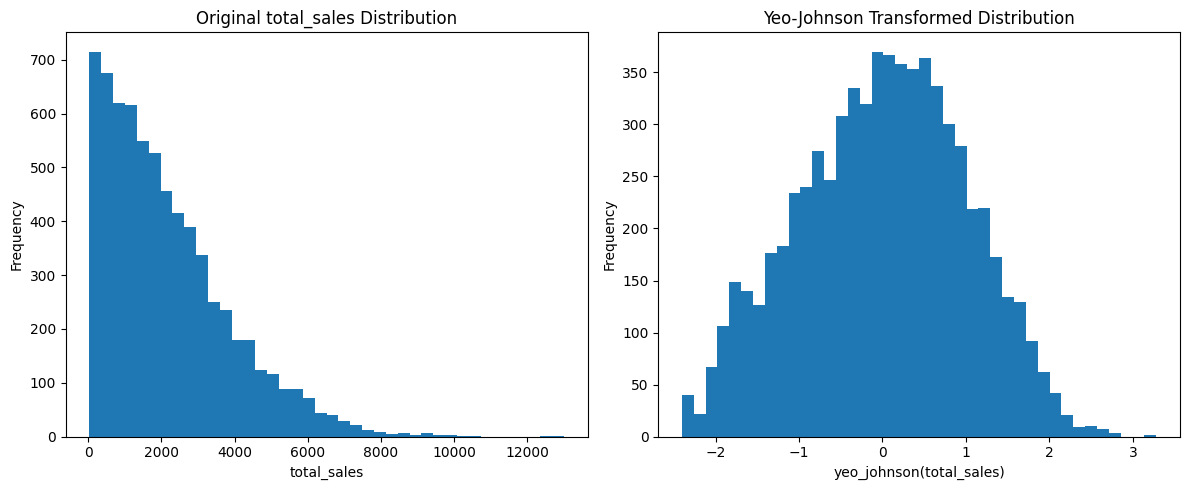

Original skewness: 1.15
Yeo-Johnson skewness: -0.08
Fitted lambda: 0.3486


In [81]:
# Original values
original = train["total_sales"]

# Yeo-Johnson transformed values
pt = PowerTransformer(method='yeo-johnson')
yj_transformed = pt.fit_transform(original.values.reshape(-1, 1)).flatten()

# Create figure
plt.figure(figsize=(12, 5))

# Original distribution
plt.subplot(1, 2, 1)
plt.hist(original, bins=40)
plt.title("Original total_sales Distribution")
plt.xlabel("total_sales")
plt.ylabel("Frequency")

# Yeo-Johnson transformed distribution
plt.subplot(1, 2, 2)
plt.hist(yj_transformed, bins=40)
plt.title("Yeo-Johnson Transformed Distribution")
plt.xlabel("yeo_johnson(total_sales)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Print statistics
print("Original skewness:", round(original.skew(), 2))
print("Yeo-Johnson skewness:", round(pd.Series(yj_transformed).skew(), 2))
print("Fitted lambda:", round(pt.lambdas_[0], 4))

### Chis function 
chris Eda function 

In [82]:
def plot_features_dual_axis(
    df: pd.DataFrame,
    cols: list[str],
    target_col: float,
    n_bins: int = 10,
    n_wide: int = 3,
    figsize_per_plot: tuple[float, float] = (5, 4),
    int_as_cat_unique_max: int | None = 20,
    cat_order: dict[str, list] | None = None,   # <-- NEW
):
    BAR_COLOR = "tab:blue"
    LINE_COLOR = "tab:orange"

    def is_categorical(s: pd.Series) -> bool:
        return s.dtype == "object" or pd.api.types.is_string_dtype(s)

    n_cols = len(cols)
    n_rows = int(np.ceil(n_cols / n_wide))

    fig, axes = plt.subplots(
        n_rows,
        n_wide,
        figsize=(figsize_per_plot[0] * n_wide, figsize_per_plot[1] * n_rows),
    )

    axes = np.atleast_1d(axes).ravel()

    for i, col in enumerate(cols):
        ax1 = axes[i]
        col_safe = col.replace("_", r"\_")

        n_nan = df[col].isna().sum()
        n_unique = df[col].nunique(dropna=True)

        tmp = df[[col, target_col]].dropna()
        if tmp.empty:
            ax1.set_title(
                rf"$\bf{{{col_safe}}}$"
                f"\n(empty after dropna; {n_unique} unique, {n_nan} nan)"
            )
            continue

        x = tmp[col]
        y = tmp[target_col]

        # ---------- TRUE CATEGORICAL ----------
        if is_categorical(x):
            type_str = "categorical"

            # base counts / means
            counts = x.value_counts()
            mean_y = tmp.groupby(col)[target_col].mean()

            # ---- APPLY USER-DEFINED CATEGORY ORDER (if provided) ----
            if cat_order is not None and col in cat_order:
                desired = list(cat_order[col])

                # keep only categories present in data
                ordered = [c for c in desired if c in counts.index]

                # append any remaining categories not specified by user
                remaining = [c for c in counts.index if c not in ordered]
                final_order = ordered + remaining
            else:
                final_order = sorted(counts.index)

            counts = counts.loc[final_order]
            mean_y = mean_y.loc[final_order]

            xpos = np.arange(len(final_order))

            ax1.bar(xpos, counts.values, alpha=0.6, color=BAR_COLOR)
            ax1.set_xlabel(col)
            ax1.set_ylabel("Count", color=BAR_COLOR)
            ax1.tick_params(axis="y", colors=BAR_COLOR)

            ax1.set_xticks(xpos)
            ax1.set_xticklabels(final_order, rotation=45, ha="right")

            ax2 = ax1.twinx()
            ax2.plot(xpos, mean_y.values, marker="o", color=LINE_COLOR)
            ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
            ax2.tick_params(axis="y", colors=LINE_COLOR)

            ax1.set_title(
                rf"$\bf{{{col_safe}}}$: Count vs Mean {target_col}"
                f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
            )

        # ---------- NUMERIC ----------
        else:
            type_str = "numeric"

            xvals = x.values
            yvals = y.values

            mask = np.isfinite(xvals) & np.isfinite(yvals)
            xvals = xvals[mask]
            yvals = yvals[mask]

            if len(xvals) == 0:
                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )
                continue

            unique_vals = np.sort(np.unique(xvals))
            n_unique_eff = len(unique_vals)

            # --- Case 1: int-as-categorical ---
            if int_as_cat_unique_max is not None and n_unique_eff <= int_as_cat_unique_max:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                xpos = np.arange(n_unique_eff)

                ax1.bar(xpos, counts, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                rotate = 45 if n_unique_eff > n_bins else 0
                step = max(int(np.ceil(n_unique_eff / n_bins)), 1)
                tick_idx = np.arange(0, n_unique_eff, step)

                if pd.api.types.is_integer_dtype(x):
                    tick_labels = unique_vals[tick_idx].astype(int)
                else:
                    tick_labels = unique_vals[tick_idx]

                ax1.set_xticks(tick_idx)
                ax1.set_xticklabels(
                    tick_labels,
                    rotation=rotate,
                    ha="right" if rotate else "center",
                )

                ax2 = ax1.twinx()
                ax2.plot(xpos, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 2: low-cardinality numeric bins ---
            elif n_unique_eff < n_bins:
                counts = np.array([(xvals == v).sum() for v in unique_vals])
                mean_y = np.array([yvals[xvals == v].mean() for v in unique_vals])

                width = 0.8 * (np.min(np.diff(unique_vals)) if n_unique_eff > 1 else 1.0)

                ax1.bar(unique_vals, counts, width=width, alpha=0.6, color=BAR_COLOR)
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(unique_vals, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Per-Value Count vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

            # --- Case 3: regular histogram ---
            else:
                bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
                bin_centers = 0.5 * (bins[:-1] + bins[1:])

                counts, _ = np.histogram(xvals, bins=bins)
                bin_idx = np.digitize(xvals, bins) - 1

                mean_y = np.array([
                    yvals[bin_idx == j].mean() if np.any(bin_idx == j) else np.nan
                    for j in range(n_bins)
                ])

                ax1.bar(
                    bin_centers,
                    counts,
                    width=(bins[1] - bins[0]),
                    alpha=0.6,
                    color=BAR_COLOR,
                )
                ax1.set_xlabel(col)
                ax1.set_ylabel("Count", color=BAR_COLOR)
                ax1.tick_params(axis="y", colors=BAR_COLOR)

                ax2 = ax1.twinx()
                ax2.plot(bin_centers, mean_y, marker="o", color=LINE_COLOR)
                ax2.set_ylabel(f"Mean {target_col}", color=LINE_COLOR)
                ax2.tick_params(axis="y", colors=LINE_COLOR)

                ax1.set_title(
                    rf"$\bf{{{col_safe}}}$: Histogram vs Mean {target_col}"
                    f"\n({type_str} with {n_unique} unique and {n_nan} nan)"
                )

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

In [83]:
FEATURES = list( train.columns[1:-1] )
print(f"There are {len(FEATURES)} features:")
print(FEATURES)

There are 11 features:
['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format']


In [84]:
train.columns

Index(['id', 'product_code', 'product_weight_kg', 'fat_content',
       'shelf_visibility', 'product_category', 'product_price', 'store_code',
       'store_age_years', 'store_size', 'store_location_tier', 'store_format',
       'total_sales'],
      dtype='object')

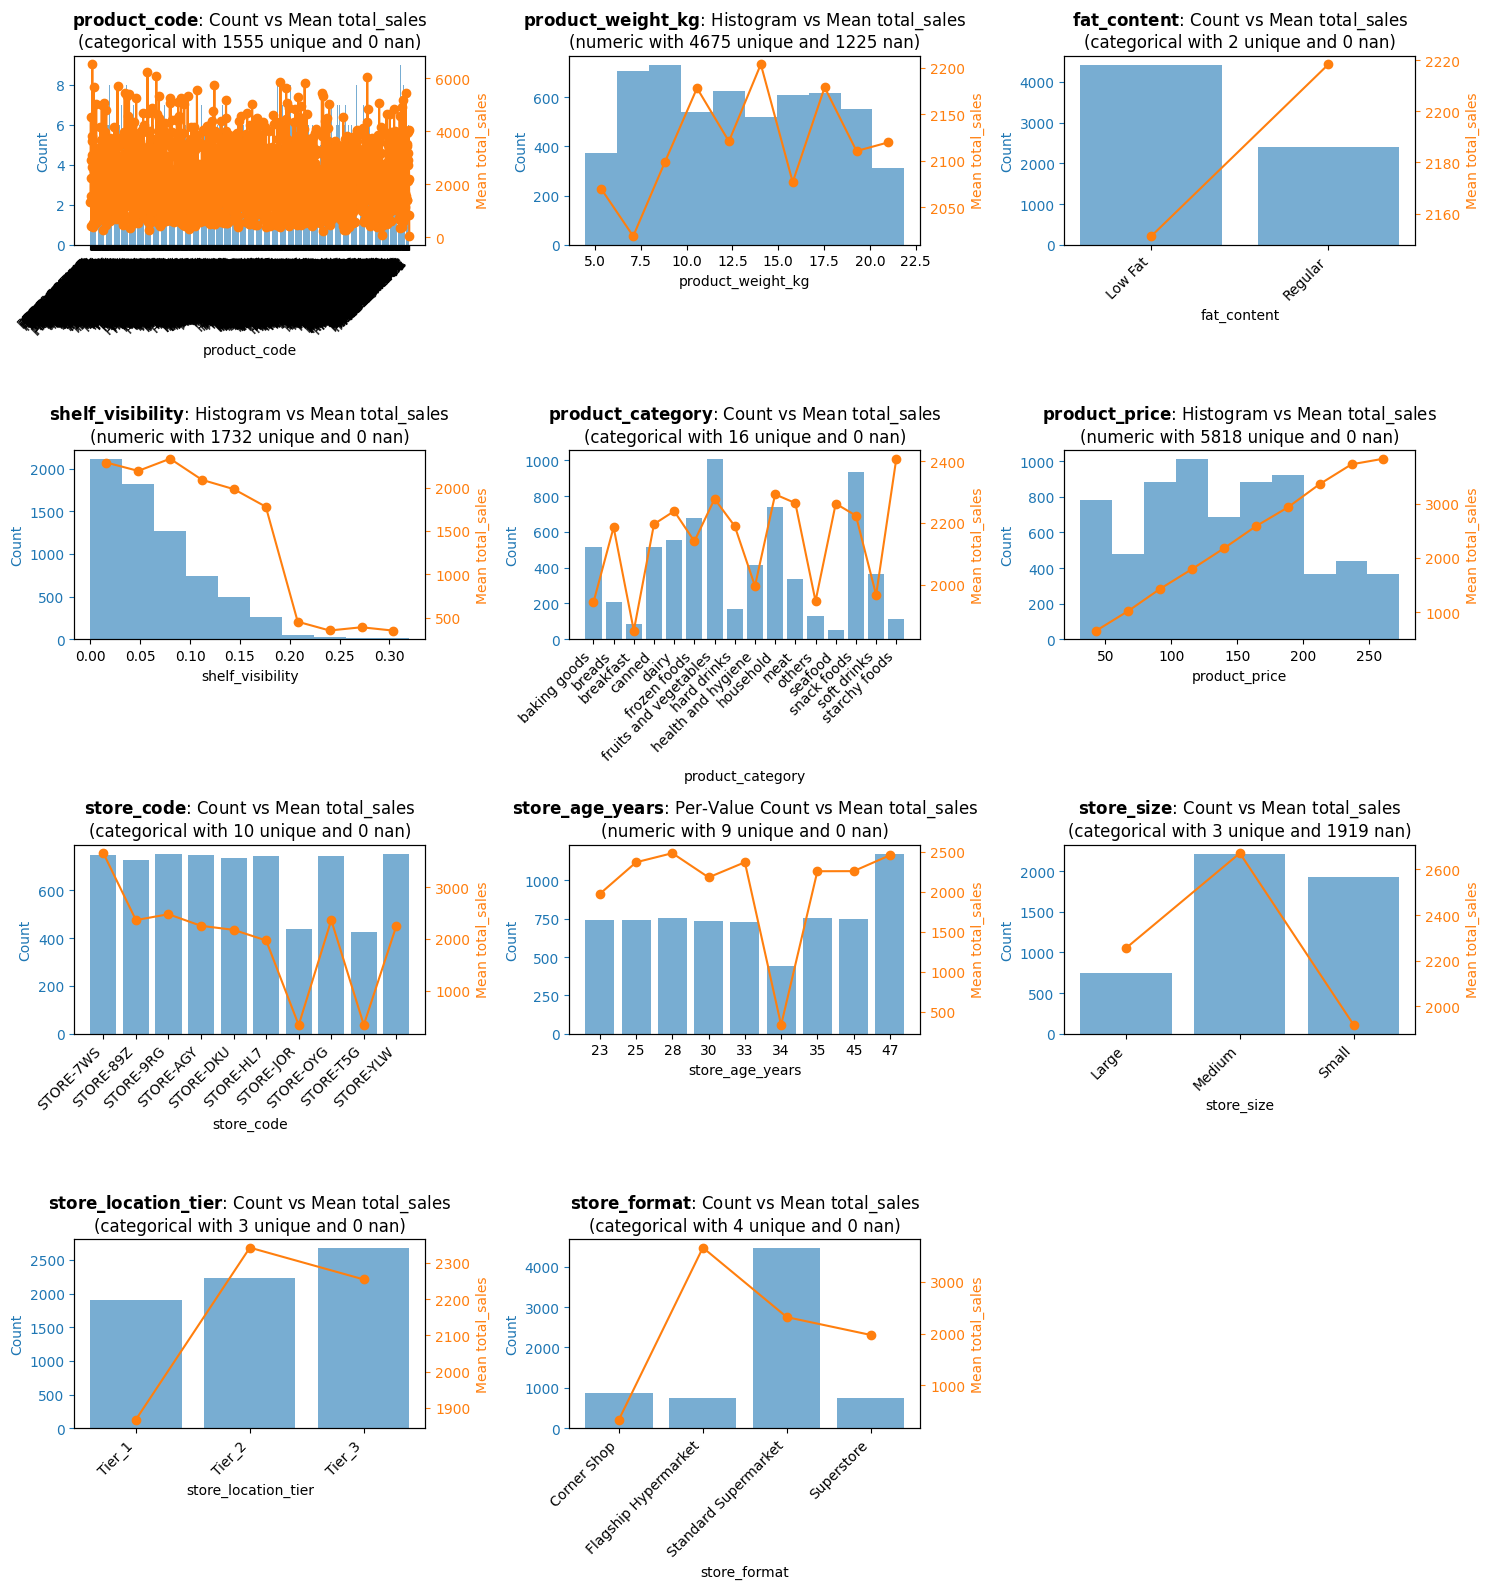

In [85]:
plot_features_dual_axis(
    train,
    cols=FEATURES,
    target_col="total_sales",
    n_bins=10,
    n_wide=3,
    int_as_cat_unique_max=20,
    cat_order = {},
)

## the 99th percentile problem 
root mean squared error penalizes the model not geting the distance right of the few models 
and this is for the outliers the 99th percentile which are from 7k to 10k total_sales they are outliers 
and they are lowering our rmse score so this analysis is on it 

our model trains and gets the lower percentile but not the higher percentile 

In [4]:
threshold = train['total_sales'].quantile(0.99)
top_tail = train[train['total_sales'] >= threshold]
print(top_tail[['store_format', 'product_category', 'store_size']].describe(include='all'))

                store_format product_category store_size
count                     69               69         56
unique                     2               26          3
top     Flagship Hypermarket      Soft Drinks     Medium
freq                      41                7         42


In [5]:
top_tail.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,28.000000,69.000000,69.000000,69.000000,69.00000
mean,12.627750,0.060571,224.944493,40.579710,8359.78942
std,4.568278,0.040277,31.271122,8.915297,1144.17211
min,5.525000,0.000000,151.820000,25.000000,7262.70000
25%,8.796750,0.031600,193.580000,30.000000,7487.59000
50%,11.108000,0.057100,233.750000,47.000000,7986.05000
75%,16.605750,0.078200,251.510000,47.000000,9072.04000
max,20.575000,0.173000,268.580000,47.000000,12996.82000


In [9]:
top_tail["store_code"].value_counts()

store_code
STORE-7WS    41
STORE-OYG     9
STORE-YLW     5
STORE-9RG     5
STORE-AGY     4
STORE-DKU     4
STORE-89Z     1
Name: count, dtype: int64

In [11]:
top_tail.head(20)

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
121,row_00157,PRD-DH02YH,10.239,Low Fat,0.0375,fruits and vegetables,248.96,STORE-AGY,45,Large,Tier_3,Standard Supermarket,7282.29
181,row_00225,PRD-8449K6,NaN,Regular,0.0761,fruits and vegetables,212.55,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,7367.73
235,row_00292,PRD-WFA6ZI,NaN,Low Fat,0.0362,Dairy,243.69,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,10477.97
345,row_00436,PRD-679O2X,NaN,Low Fat,0.0513,Snack Foods,190.13,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,9323.55
387,row_00493,PRD-299PG3,8.417,Regular,0.0416,CANNED,183.17,STORE-YLW,35,Small,Tier_1,Standard Supermarket,7599.13
615,row_00801,PRD-OEM1VZ,NaN,Regular,0.0792,dairy,192.25,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,7986.05
625,row_00816,PRD-YW8YG4,5.525,Low Fat,0.0687,FROZEN FOODS,255.71,STORE-OYG,25,NaN,Tier_2,Standard Supermarket,8894.14
649,row_00848,PRD-HFVMHX,8.136,Low Fat,0.0186,Health and Hygiene,239.38,STORE-YLW,35,Small,Tier_1,Standard Supermarket,7438.99
714,row_00927,PRD-6NJX8K,NaN,Low Fat,0.0375,household,236.23,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,7581.74
745,row_00961,PRD-THVKB8,NaN,Regular,0.0859,dairy,257.16,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,9523.15
